In [1]:
import sys
import os
os.chdir("/home/karlandersson/Programming/MasterThesisProject")
print(os.getcwd())

/home/karlandersson/Programming/MasterThesisProject


In [2]:
import json
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import numpy as np

from utils.heatpipe_utils import generate_cfgs_seq, generate_cfg, plot_heatpipe_solutions
from utils.solver import Solver

from coupled.heatpipe import Heatpipe

import utils.sodium_properties as s_props

%config InlineBackend.figure_format = "retina"

Mesh warning: N_Z changed from 50 to 46
Mesh warning: Neutronics N_Z changed from 50 to 30
Mesh warning: N_R changed from 15 to 65


In [3]:
with open("data/vapour_data.json", "r") as f:
    exp_data = json.load(f)
    data_560 = exp_data["data_guoju_560"]
    
cfg_560     = generate_cfg(data_560, 30, 100, data_560["bc"]["Q"])
cfg_560_cos = generate_cfg(data_560, 30, 100, data_560["bc"]["Q"])
cfg_560_lin = generate_cfg(data_560, 30, 100, data_560["bc"]["Q"])

L = cfg_560.geometry.l_evap
N = cfg_560.mesh.N_evap
Q = data_560["bc"]["Q"]

z = np.linspace(0, L, N)
q_cos_shape = np.sin(np.pi*z/L)
q_cos = Q * q_cos_shape / np.sum(q_cos_shape)

q_lin = Q * z[::-1] / np.sum(z)

cfg_560_cos.bc.Q = q_cos
cfg_560_lin.bc.Q = q_lin

In [4]:
heatpipe     = Heatpipe(cfg_560)
heatpipe_cos = Heatpipe(cfg_560_cos)
heatpipe_lin = Heatpipe(cfg_560_lin)

heatpipe.solid.variable_k     = True
heatpipe.return_u             = True
heatpipe_cos.solid.variable_k = True
heatpipe_cos.return_u         = True
heatpipe_lin.solid.variable_k = True
heatpipe_lin.return_u         = True

solver = Solver([heatpipe, heatpipe_cos, heatpipe_lin])
solver.fsolve()

Running case 1 ...
Running case 2 ...
Running case 3 ...


In [133]:
plt.rcParams["font.size"]   = 30
plt.rcParams["font.family"] = "cm"
plt.rcParams["text.usetex"] = True

from matplotlib.ticker import MultipleLocator
import string

def centers_to_edges(x, first_edge=None, last_edge=None):
    edges = np.empty(len(x) + 1)
    edges[1:-1] = 0.5 * (x[:-1] + x[1:])

    edges[0] = (
        x[0] - 0.5 * (x[1] - x[0])
        if first_edge is None else first_edge
    )

    edges[-1] = (
        x[-1] + 0.5 * (x[-1] - x[-2])
        if last_edge is None else last_edge
    )

    return edges

def add_evap_heat_flux_profile(
    ax,
    cfg,
    profile="flat",
    color="black",
    lw=1.0,
    n=100,
    profile_width_mm=0.35,
    gap_mm=0.08,
    n_arrows=5,
    arrow_lw=0.6,
    arrow_mutation_scale=8,
):
    z0 = 0.0
    z1 = cfg.geometry.l_evap

    z = np.linspace(z0, z1, n)
    eta = (z - z0) / (z1 - z0)

    if profile == "flat":
        q = np.ones_like(eta)
    elif profile == "cosine":
        q = np.sin(np.pi * eta)
    elif profile == "linear":
        q = 1.0 - eta
    else:
        raise ValueError("profile must be 'flat', 'cosine', or 'linear'")

    r_wall = cfg.geometry.r_outer * 1e3
    r_base = r_wall + gap_mm
    r_prof = r_base + profile_width_mm * q

    ax.plot(
        r_prof,
        z,
        color=color,
        lw=lw,
        clip_on=False,
        zorder=20,
    )

    z_arrow = np.linspace(z0, z1, n_arrows + 2)[1:-1]
    eta_arrow = (z_arrow - z0) / (z1 - z0)

    if profile == "flat":
        q_arrow = np.ones_like(eta_arrow)
    elif profile == "cosine":
        q_arrow = np.sin(np.pi * eta_arrow)
    elif profile == "linear":
        q_arrow = 1.0 - eta_arrow

    for za, qa in zip(z_arrow, q_arrow):
        if qa <= 1e-12:
            continue

        x_tail = r_base + profile_width_mm * qa
        x_head = r_wall

        ax.annotate(
            "",
            xy=(x_head, za),
            xytext=(x_tail, za),
            arrowprops=dict(
                arrowstyle="->",
                color=color,
                lw=arrow_lw,
                mutation_scale=arrow_mutation_scale,
                shrinkA=0,
                shrinkB=0,
            ),
            clip_on=False,
            zorder=21,
        )

def generate_ax(
    solutions_list,
    heatpipe_list,
    titles=None,
    cbar_tick_step=None,
    r_major_step=None,
    r_minor_step=None,
    z_major_step=None,
    z_minor_step=None,
    cbar_minor_step=None,
    vmin=None,
    vmax=None,
    add_region_labels=True,
    region_label_color="white",
    region_label_fontsize=30,
    add_heat_flux_profiles=True,
    heat_flux_profiles=("flat", "cosine", "linear"),
    heat_flux_color="black",
    heat_flux_width_mm=0.55,
    heat_flux_gap_mm=0.08,
    heat_flux_n_arrows=6,
):
    if titles is None:
        titles = [None] * len(solutions_list)

    if vmin is None:
        vmin = min(np.min(sol[0]) for sol in solutions_list)

    if vmax is None:
        vmax = max(np.max(sol[0]) for sol in solutions_list)

    fig, axes = plt.subplots(
        1, 3,
        figsize=(13, 10),
        sharey=True,
        constrained_layout=False,
        gridspec_kw={"wspace": 0.40},
    )

    meshes = []

    for i, (ax, solutions, heatpipe, title) in enumerate(
        zip(axes, solutions_list, heatpipe_list, titles)
    ):
        T_solid, u, mach, T_vap = solutions

        R = heatpipe.solid.R
        Z = heatpipe.solid.Z
        cfg = heatpipe.cfg

        z_total = (
            cfg.geometry.l_evap
            + cfg.geometry.l_adiabatic
            + cfg.geometry.l_cond
        )

        z_evap_end = cfg.geometry.l_evap
        z_adiab_end = cfg.geometry.l_evap + cfg.geometry.l_adiabatic

        z_edges = centers_to_edges(
            Z,
            first_edge=0.0,
            last_edge=z_total,
        )

        r_edges = centers_to_edges(
            R,
            first_edge=cfg.geometry.r_vapour,
            last_edge=cfg.geometry.r_outer,
        )

        c = ax.pcolormesh(
            r_edges * 1e3,
            z_edges,
            T_solid,
            shading="flat",
            cmap="inferno",
            vmin=vmin,
            vmax=vmax,
            edgecolors="none",
            linewidth=0,
            antialiased=False,
            rasterized=True,
        )

        meshes.append(c)

        ax.axhline(z_evap_end,  color="white", linestyle="-", linewidth=0.8, alpha=0.5)
        ax.axhline(z_adiab_end, color="white", linestyle="-", linewidth=0.8, alpha=0.5)

        ax.axvline(cfg.geometry.r_wick * 1e3, color="white", linestyle="-", linewidth=0.8, alpha=0.5)
        ax.axvline(cfg.geometry.r_gap  * 1e3, color="white", linestyle="-", linewidth=0.8, alpha=0.5)

        if add_heat_flux_profiles:
            add_evap_heat_flux_profile(
                ax,
                cfg,
                profile=heat_flux_profiles[i],
                color=heat_flux_color,
                profile_width_mm=heat_flux_width_mm,
                gap_mm=heat_flux_gap_mm,
                n_arrows=heat_flux_n_arrows,
                lw=2,
                arrow_lw=2,
                arrow_mutation_scale=7,
            )

        if add_region_labels and i == len(axes) - 1:
            r_bounds = np.array([
                cfg.geometry.r_vapour,
                cfg.geometry.r_wick,
                cfg.geometry.r_gap,
                cfg.geometry.r_outer,
            ]) * 1e3

            z_bounds = np.array([
                0.0,
                z_evap_end,
                z_adiab_end,
                z_total,
            ])

            letters = string.ascii_uppercase
            n = 0

            for iz in range(len(z_bounds) - 1):
                for ir in range(len(r_bounds) - 1):
                    r_mid = 0.5 * (r_bounds[ir] + r_bounds[ir + 1])
                    z_mid = 0.5 * (z_bounds[iz] + z_bounds[iz + 1])

                    ax.text(
                        r_mid,
                        z_mid,
                        letters[n],
                        color=region_label_color,
                        fontsize=region_label_fontsize,
                        ha="center",
                        va="center",
                        fontweight="bold",
                    )

                    n += 1

        ax.set_xlabel(r"$r$ [mm]")

        if r_major_step is not None:
            ax.xaxis.set_major_locator(MultipleLocator(r_major_step))

        if r_minor_step is not None:
            ax.xaxis.set_minor_locator(MultipleLocator(r_minor_step))

        if z_major_step is not None:
            ax.yaxis.set_major_locator(MultipleLocator(z_major_step))

        if z_minor_step is not None:
            ax.yaxis.set_minor_locator(MultipleLocator(z_minor_step))

        if title is not None:
            ax.set_title(title)

        if i != 0:
            ax.tick_params(labelleft=False)

        ax.tick_params(axis="x", labelrotation=35)

        ax.set_xlim(
            cfg.geometry.r_vapour * 1e3,
            cfg.geometry.r_outer * 1e3,
        )

    axes[0].set_ylabel(r"$z$ [m]")

    fig.subplots_adjust(
        left=0.15,
        right=0.90,
        bottom=0.14,
        top=0.88,
        wspace=0.40,
    )

    cbar = fig.colorbar(
        meshes[0],
        ax=axes,
        label=r"$T$ [K]",
        shrink=1.0,
        pad=0.08
    )

    if cbar_tick_step is not None:
        cbar.ax.yaxis.set_major_locator(MultipleLocator(cbar_tick_step))

    if cbar_minor_step is not None:
        cbar.ax.yaxis.set_minor_locator(MultipleLocator(cbar_minor_step))

    return fig, axes

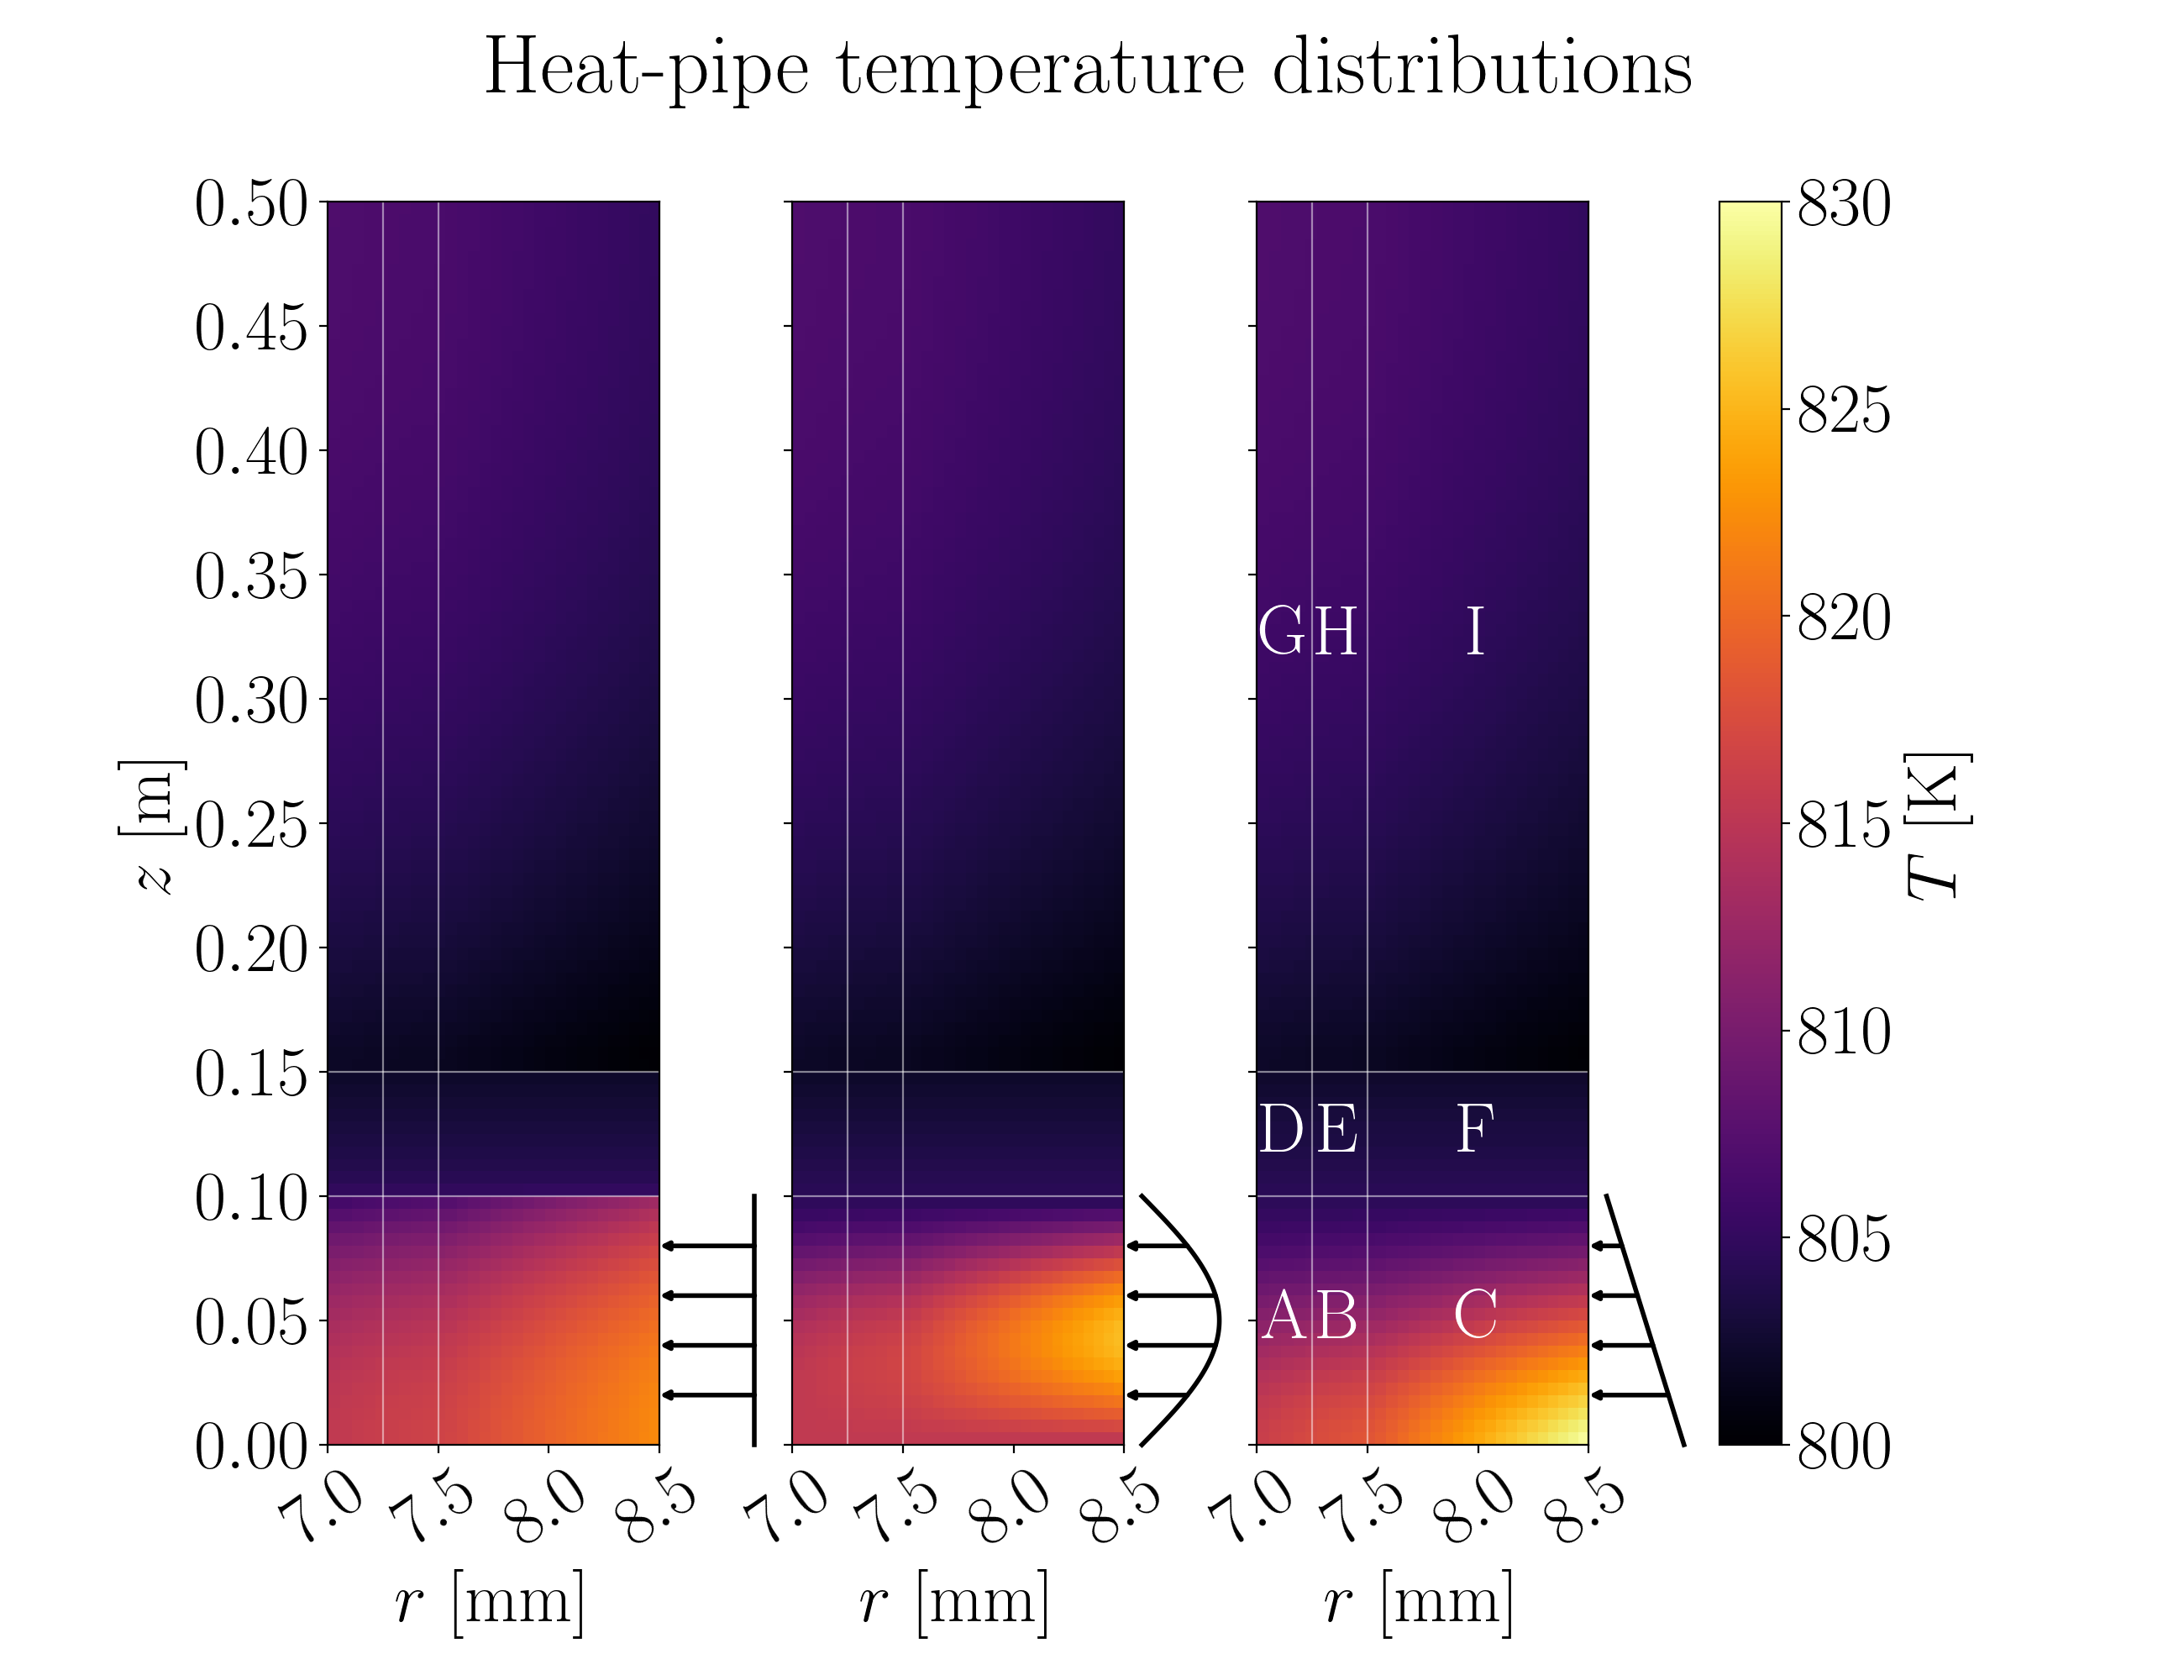

In [135]:
%config InlineBackend.print_figure_kwargs = {'bbox_inches': None}

fig, axes = generate_ax(
    solver.solutions,
    [heatpipe, heatpipe_cos, heatpipe_lin],
    r_major_step=0.5,
    z_major_step=0.05,
    heat_flux_profiles=("flat", "cosine", "linear"),
    heat_flux_width_mm=0.35,
    heat_flux_gap_mm=0.08,
    heat_flux_n_arrows=4,
    heat_flux_color="black",
    vmin=800,
    vmax=830
)

fig.suptitle(
    r"Heat-pipe temperature distributions",
    x=0.5,
    y=0.98,
    ha="center",
)

plt.savefig("outputs/report_figures/solid_validations.pdf")
plt.show()

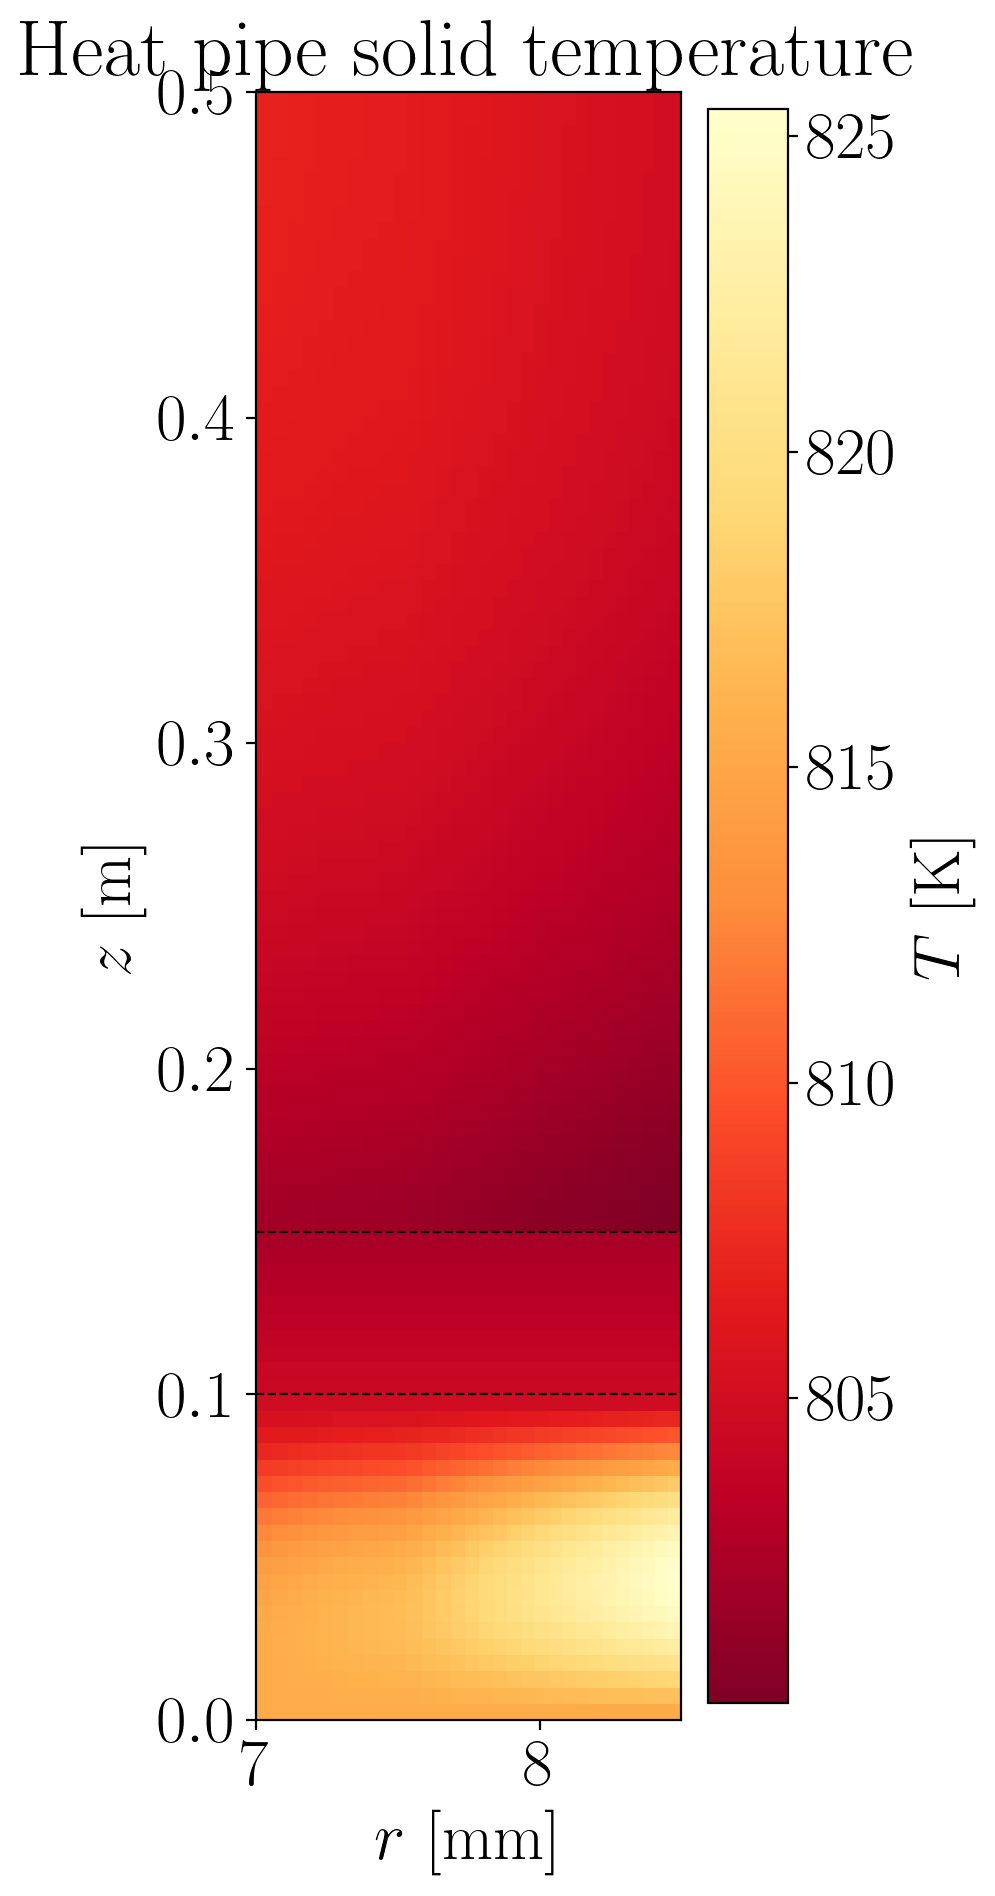

In [7]:
fig, ax = generate_ax(solver.solutions[1], heatpipe_cos)

ax.set_title("Heat pipe solid temperature")

fig.tight_layout()
plt.show()

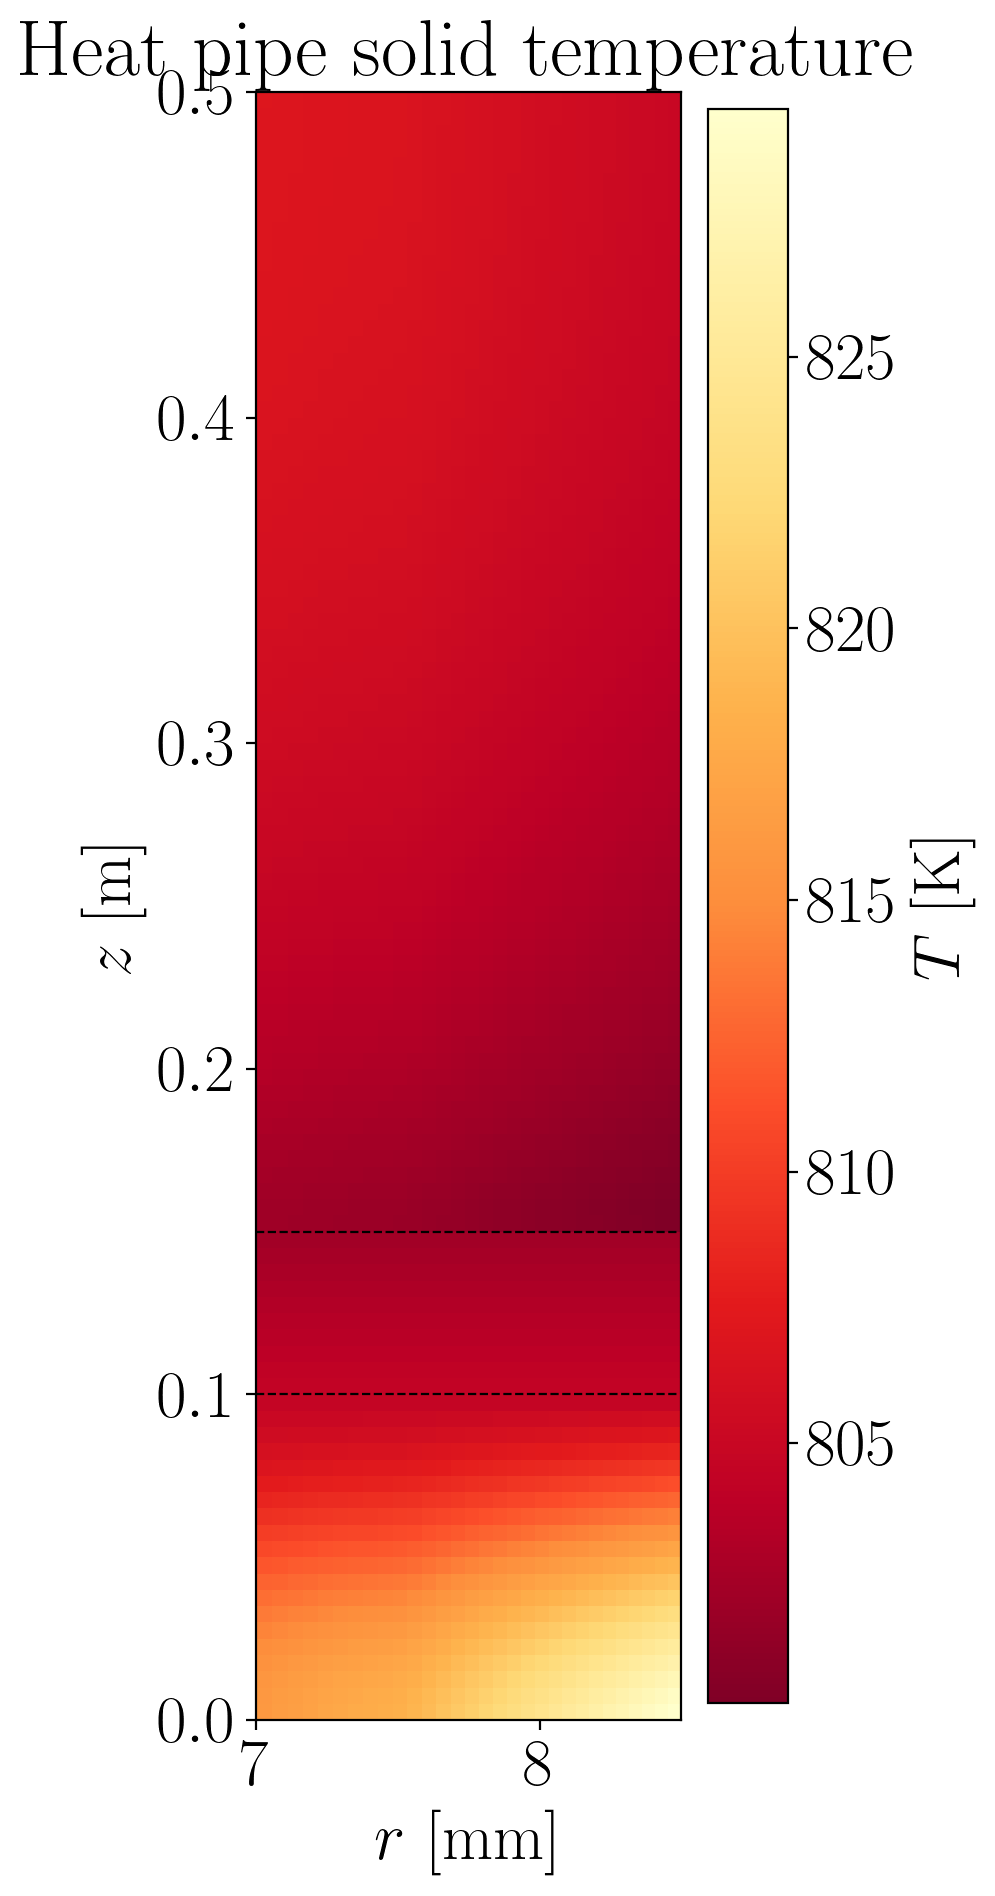

In [8]:
fig, ax = generate_ax(solver.solutions[2], heatpipe_lin)

ax.set_title("Heat pipe solid temperature")

fig.tight_layout()
plt.show()